# *FOOD WASTE MANAGEMENT SYSTEM* #

### IMPORTANT URLs ###

Github: https://github.com/lubnaibm/Food-Waste-Management-System  

Streamlit app: https://food-waste-management-system-kpbqj6arubkuuh7ssmiy7j.streamlit.app/  
food_waste_management.ipynb html file: file:///C:/Users/Amir%20ji/Downloads/food_waste_management.html

In [1]:
!pip install pandas numpy matplotlib seaborn sqlalchemy pymysql



### Importing important libraries ###

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### Fetching datasets ###

In [3]:
df1 = pd.read_csv("providers_data.csv")
df2 = pd.read_csv("receivers_data.csv")
df3 = pd.read_csv("food_listings_data.csv")
df4 = pd.read_csv("claims_data.csv")

### Data inspection and cleaninig ###

In [48]:
df1.head(5)

,Provider_ID,Name,Type,Address,City,Contact
0,1,Gonzales-Cochran,Supermarket,"74347 Christopher Extensions\nAndreamouth, OK ...",New Jessica,16002200480
1,2,"Nielsen, Johnson and Fuller",Grocery Store,"91228 Hanson Stream\nWelchtown, OR 27136",East Sheena,192528389016297
2,3,Miller-Black,Supermarket,"561 Martinez Point Suite 507\nGuzmanchester, W...",Lake Jesusview,0015172952206
3,4,"Clark, Prince and Williams",Grocery Store,"467 Bell Trail Suite 409\nPort Jesus, IA 61188",Mendezmouth,5569448935401
4,5,Coleman-Farley,Grocery Store,"078 Matthew Creek Apt. 319\nSaraborough, MA 53978",Valentineside,1937146577


In [49]:
df2.head(5)

,Receiver_ID,Name,Type,City,Contact
0,1,Donald Gomez,Shelter,Port Carlburgh,9559225295
1,2,Laurie Ramos,Individual,Lewisburgh,7610421570
2,3,Ashley Mckee,NGO,South Randalltown,6910230094856
3,4,Erika Rose,NGO,South Shaneville,8296491111
4,5,John Romero,Individual,Bakerport,0674910154


In [12]:
df3.head(5)

,Food_ID,Food_Name,Quantity,Expiry_Date,Provider_ID,Provider_Type,Location,Food_Type,Meal_Type
0,1,Bread,43,2025-03-17,110,Grocery Store,South Kellyville,Non-Vegetarian,Breakfast
1,2,Soup,22,2025-03-24,791,Grocery Store,West James,Non-Vegetarian,Dinner
2,3,Fruits,46,2025-03-28,478,Catering Service,Lake Regina,Vegan,Breakfast
3,4,Fruits,15,2025-03-16,930,Restaurant,Kellytown,Vegan,Lunch
4,5,Soup,14,2025-03-19,279,Restaurant,Garciaport,Vegan,Dinner


In [50]:
df4.head(5)

,Claim_ID,Food_ID,Receiver_ID,Status,Timestamp
0,1,164,908,Pending,2025-03-05 05:26:00
1,2,353,391,Cancelled,2025-03-11 10:24:00
2,3,626,492,Completed,2025-03-21 00:59:00
3,4,61,933,Cancelled,2025-03-04 09:08:00
4,5,345,229,Pending,2025-03-14 15:17:00


In [5]:
print(df1.shape)
print(df2.shape)
print(df3.shape)
print(df4.shape)

(1000, 6)
(1000, 5)
(1000, 9)
(1000, 5)


#### Changing to proper Date Time Format ####

In [6]:
df3['Expiry_Date'] = pd.to_datetime(df3['Expiry_Date'])
df4['Timestamp'] = pd.to_datetime(df4['Timestamp'])


#### Checking for null values ####

In [7]:
# Check missing values
print(df1.isnull().sum())
print(df2.isnull().sum())
print(df3.isnull().sum())
print(df4.isnull().sum())

Provider_ID    0
Name           0
Type           0
Address        0
City           0
Contact        0
dtype: int64
Receiver_ID    0
Name           0
Type           0
City           0
Contact        0
dtype: int64
Food_ID          0
Food_Name        0
Quantity         0
Expiry_Date      0
Provider_ID      0
Provider_Type    0
Location         0
Food_Type        0
Meal_Type        0
dtype: int64
Claim_ID       0
Food_ID        0
Receiver_ID    0
Status         0
Timestamp      0
dtype: int64


No null values found

#### Checking for Duplicated data ####

In [8]:
df1.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [9]:
df2.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [10]:
df3.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [11]:
df4.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

No Duplicated data found in any of the data frame

### Checking for Datatypes ###

In [14]:
df1.dtypes

Provider_ID     int64
Name           object
Type           object
Address        object
City           object
Contact        object
dtype: object

In [15]:
df2.dtypes


Receiver_ID     int64
Name           object
Type           object
City           object
Contact        object
dtype: object

In [16]:
df3.dtypes

Food_ID                   int64
Food_Name                object
Quantity                  int64
Expiry_Date      datetime64[ns]
Provider_ID               int64
Provider_Type            object
Location                 object
Food_Type                object
Meal_Type                object
dtype: object

In [17]:
df4.dtypes

Claim_ID                int64
Food_ID                 int64
Receiver_ID             int64
Status                 object
Timestamp      datetime64[ns]
dtype: object

In [18]:
#City Naming Mismatch
#In df1 → City
#In df3 → Location
#These represent the same thing but have different column names
df3.rename(columns={'Location': 'City'}, inplace=True)

In [19]:
# Validate that all food quqnties are positive to ensure logical consistency.
df3 = df3[df3['Quantity'] > 0]


In [20]:
#inconsistant contact numbers in df1=Providers dataset and dff2= Recievers dataset
#Change to standard format:
df1['Contact'] = df1['Contact'].str.replace(r'\D', '', regex=True)
df2['Contact'] = df2['Contact'].str.replace(r'\D', '', regex=True)



In [21]:
df1.head(5)

,Provider_ID,Name,Type,Address,City,Contact
0,1,Gonzales-Cochran,Supermarket,"74347 Christopher Extensions\nAndreamouth, OK ...",New Jessica,16002200480
1,2,"Nielsen, Johnson and Fuller",Grocery Store,"91228 Hanson Stream\nWelchtown, OR 27136",East Sheena,192528389016297
2,3,Miller-Black,Supermarket,"561 Martinez Point Suite 507\nGuzmanchester, W...",Lake Jesusview,0015172952206
3,4,"Clark, Prince and Williams",Grocery Store,"467 Bell Trail Suite 409\nPort Jesus, IA 61188",Mendezmouth,5569448935401
4,5,Coleman-Farley,Grocery Store,"078 Matthew Creek Apt. 319\nSaraborough, MA 53978",Valentineside,1937146577


In [22]:
# both df1= Providers and df3= food_listings have provider type column that can cause data redundancy so, dropping the column from df3
df3.drop(columns=['Provider_Type'], inplace=True)


In [23]:
df3.columns

Index(['Food_ID', 'Food_Name', 'Quantity', 'Expiry_Date', 'Provider_ID',
       'City', 'Food_Type', 'Meal_Type'],
      dtype='object')

In [24]:
#Statistic Summary:
print(df1.describe)
print(df2.describe)
print(df3.describe)
print(df4.describe)

<bound method NDFrame.describe of      Provider_ID                         Name              Type  \
0              1             Gonzales-Cochran       Supermarket   
1              2  Nielsen, Johnson and Fuller     Grocery Store   
2              3                 Miller-Black       Supermarket   
3              4   Clark, Prince and Williams     Grocery Store   
4              5               Coleman-Farley     Grocery Store   
..           ...                          ...               ...   
995          996    Vasquez, Ruiz and Flowers        Restaurant   
996          997               Garza-Williams  Catering Service   
997          998                  Novak Group     Grocery Store   
998          999                    Moody Ltd     Grocery Store   
999         1000               Jenkins-Brooks        Restaurant   

                                               Address            City  \
0    74347 Christopher Extensions\nAndreamouth, OK ...     New Jessica   
1            

# **Distribution of Variables** #


## *Quantity  Distribution* ##

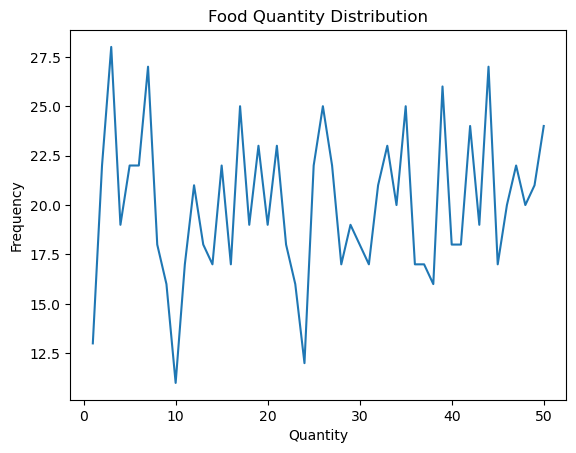

In [51]:
df3['Quantity'].value_counts().sort_index().plot(kind='line')
plt.title("Food Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()


Food quantities are spread across many values, not concentrated in one range
Food donations are inconsistent, not standardized

## **Food Type** ##

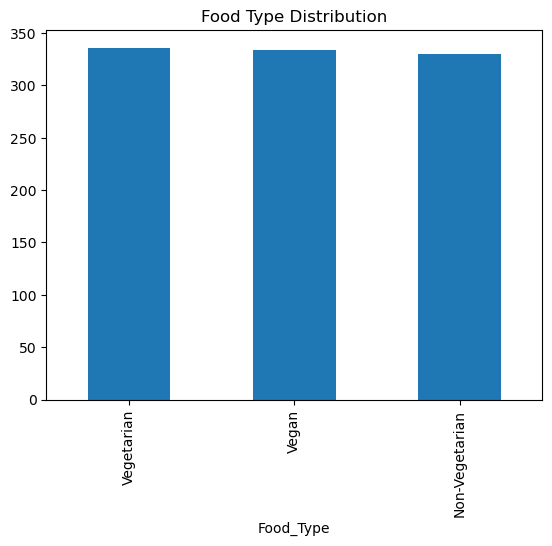

In [26]:
df3['Food_Type'].value_counts().plot(kind='bar')
plt.title("Food Type Distribution")
plt.show()


The type of the food is almost equally distributed among vegetarians, nonn-vegetarians and vegans
Very balanced distribution
System supports all dietary types equally.

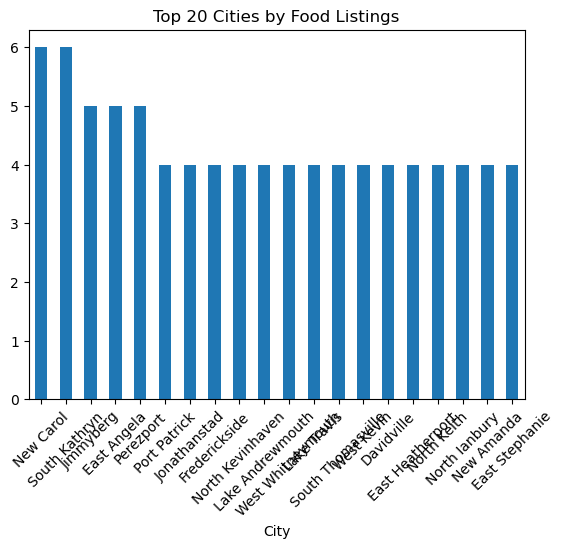

In [52]:
# Top 10 cities contributing to food

top_cities = df3['City'].value_counts().head(20)

top_cities.plot(kind='bar')
plt.title("Top 20 Cities by Food Listings")
plt.xticks(rotation=45)
plt.show()



Some cities contribute more food (top cities have 5–6 listings)
Food supply is uneven geographically
Certain cities are more active that can become potential hubs

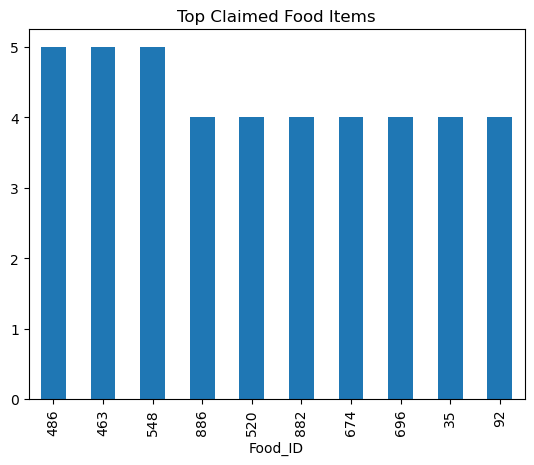

In [28]:
claims_per_food = df4['Food_ID'].value_counts()
claims_per_food.head(10).plot(kind='bar')
plt.title("Top Claimed Food Items")
plt.show()




Some Food_IDs are claimed up to 5 times
Certain foods are high-demand
we should identify those foods and prioritize them

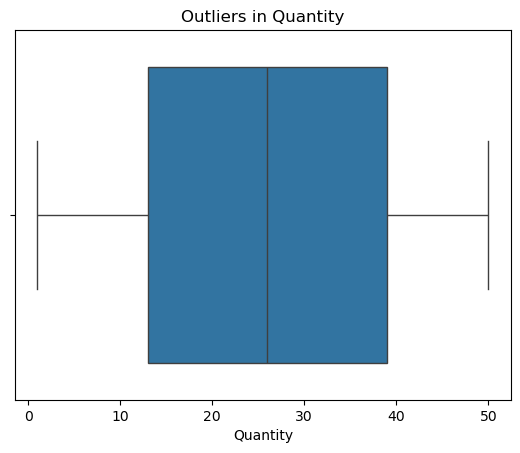

In [29]:
sns.boxplot(x=df3['Quantity'])
plt.title("Outliers in Quantity")
plt.show()


Presence of outliers indicates that some providers donate very large quantities

In [30]:
df3.corr(numeric_only=True)


,Food_ID,Quantity,Provider_ID
Food_ID,1.000000,-0.012883,0.005130
Quantity,-0.012883,1.000000,-0.045996
Provider_ID,0.005130,-0.045996,1.000000


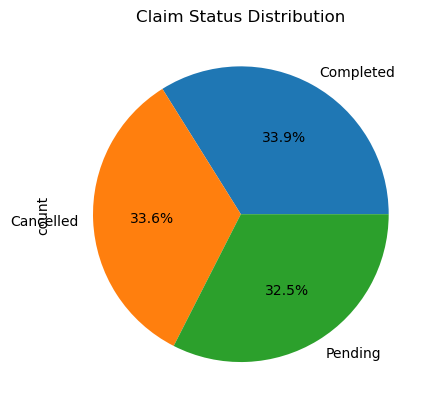

In [31]:
df4['Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Claim Status Distribution")
plt.show()


Almost 1/3 claims are cancelled this indicates system inefficiency (logistics, delays, mismatch)

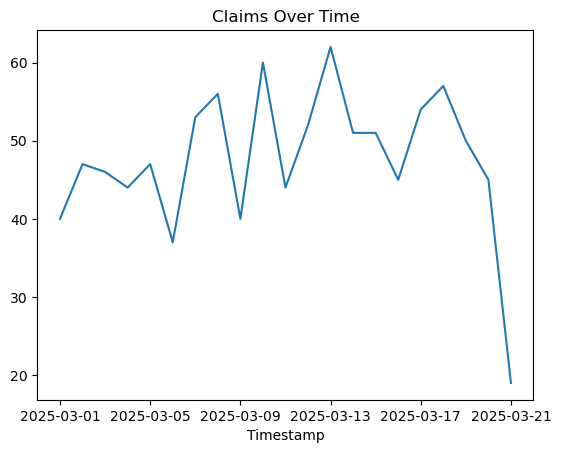

In [32]:
df4['Timestamp'].dt.date.value_counts().sort_index().plot()
plt.title("Claims Over Time")
plt.show()


Claims fluctuate daily that means:
Demand is not stable
Might depend on day/time/events

In [33]:
df3['Quantity'].std()


14.609894353246123

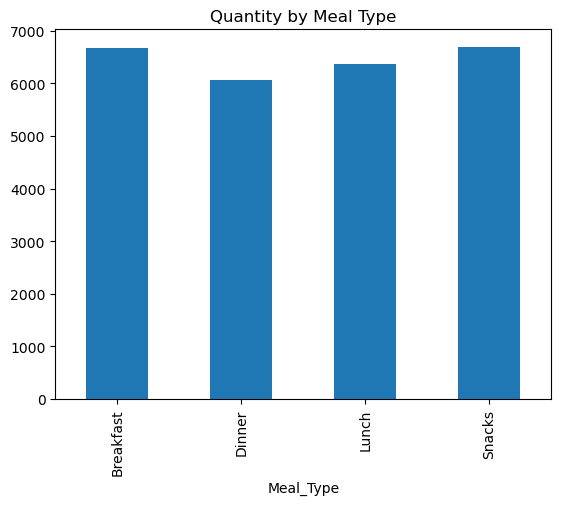

In [34]:
df3.groupby('Meal_Type')['Quantity'].sum().plot(kind='bar')
plt.title("Quantity by Meal Type")
plt.show()


Breakfast is most demanded
we should focus redistribution efforts there

In [35]:
expired = df3[df3['Expiry_Date'] < datetime.now()]
print(expired.head())

   Food_ID Food_Name  Quantity Expiry_Date  Provider_ID              City  \
0        1     Bread        43  2025-03-17          110  South Kellyville   
1        2      Soup        22  2025-03-24          791        West James   
2        3    Fruits        46  2025-03-28          478       Lake Regina   
3        4    Fruits        15  2025-03-16          930         Kellytown   
4        5      Soup        14  2025-03-19          279        Garciaport   

        Food_Type  Meal_Type  
0  Non-Vegetarian  Breakfast  
1  Non-Vegetarian     Dinner  
2           Vegan  Breakfast  
3           Vegan      Lunch  
4           Vegan     Dinner  


In [36]:
df4.merge(df3, on='Food_ID').shape


(1000, 12)

 # 2. Database Creation  #

## Storing food availability data in SQL tables. ##

In [37]:

from sqlalchemy import create_engine

# Create SQLite database

engine = create_engine("sqlite:///C:/Users/Amir ji/OneDrive/Desktop/food_waste_management/food_waste_management.db")

df1.to_sql('providers', con=engine, if_exists='replace', index=False)
df2.to_sql('receivers', con=engine, if_exists='replace', index=False)
df3.to_sql('food_listings', con=engine, if_exists='replace', index=False)
df4.to_sql('claims', con=engine, if_exists='replace', index=False)


1000

# CRUD OPERATIONS #

## CREATE ##


In [39]:
from sqlalchemy import text

with engine.connect() as conn:
    conn.execute(text("""
    INSERT INTO providers (Provider_ID, Name, Type, Address, City, Contact)
    VALUES (1001, 'New Restaurant', 'Restaurant', 'Some Address', 'New York', '9999999999')
    """))
    conn.commit()


## READ ##

In [40]:
df = pd.read_sql("SELECT * FROM providers", engine)
df.head()


,Provider_ID,Name,Type,Address,City,Contact
0,1,Gonzales-Cochran,Supermarket,"74347 Christopher Extensions\nAndreamouth, OK ...",New Jessica,16002200480
1,2,"Nielsen, Johnson and Fuller",Grocery Store,"91228 Hanson Stream\nWelchtown, OR 27136",East Sheena,192528389016297
2,3,Miller-Black,Supermarket,"561 Martinez Point Suite 507\nGuzmanchester, W...",Lake Jesusview,0015172952206
3,4,"Clark, Prince and Williams",Grocery Store,"467 Bell Trail Suite 409\nPort Jesus, IA 61188",Mendezmouth,5569448935401
4,5,Coleman-Farley,Grocery Store,"078 Matthew Creek Apt. 319\nSaraborough, MA 53978",Valentineside,1937146577


## UPDATE ##

In [41]:
with engine.connect() as conn:
    conn.execute(text("""
    UPDATE food_listings
    SET Quantity = 200
    WHERE Food_ID = 1
    """))
    conn.commit()


## DELETE ##

In [42]:
with engine.connect() as conn:
    conn.execute(text("""
    DELETE FROM claims
    WHERE Claim_ID = 5
    """))
    conn.commit()



## Important SQL Queries ##

In [57]:
query = """
SELECT City, COUNT(*) AS total_providers
FROM providers
GROUP BY City
ORDER BY total_providers DESC;
"""
pd.read_sql(query, engine)


,City,total_providers
0,South Christopherborough,3
1,New Carol,3
2,Williamview,2
3,West Lauraborough,2
4,West Christopher,2
...,...,...
959,Alexanderchester,1
960,Aguirreville,1
961,Adamsville,1
962,Adamsview,1


Large supply indicate system has strong donation base

In [53]:
# Providers per city
query = """
SELECT p.Type, SUM(f.Quantity) AS total_food
FROM food_listings f
JOIN providers p ON f.Provider_ID = p.Provider_ID
GROUP BY p.Type
ORDER BY total_food DESC;
"""
pd.read_sql(query, engine)

,Type,total_food
0,Restaurant,6923
1,Supermarket,6696
2,Grocery Store,6216
3,Catering Service,6116


Restaurants are top contributors
we can target them for partnerships

In [58]:
# Recievers per city
query = """
SELECT City, COUNT(*) AS total_receivers
FROM receivers
GROUP BY City
ORDER BY total_receivers DESC;
"""
pd.read_sql(query, engine)


,City,total_receivers
0,New Christopher,3
1,Williamsfort,2
2,West Richard,2
3,West James,2
4,Stevenmouth,2
...,...,...
961,Alexanderbury,1
962,Aguilarstad,1
963,Aguilarbury,1
964,Adamland,1


In [59]:
# Top provider type
query = """
SELECT Type, COUNT(*) AS total
FROM providers
GROUP BY Type
ORDER BY total DESC;
"""
pd.read_sql(query, engine)


,Type,total
0,Supermarket,262
1,Grocery Store,256
2,Restaurant,247
3,Catering Service,236


Supply sources are well distributed
No single dependency → good system stability

In [61]:
# Total food available
query = """
SELECT SUM(Quantity) AS total_food
FROM food_listings;
"""
pd.read_sql(query, engine)



,total_food
0,25951


Total Food Available= 25,951 units
Large supply indicates system has strong donation base

In [62]:
# City with most food listings
query = """
SELECT City, COUNT(*) AS listings
FROM food_listings
GROUP BY City
ORDER BY listings DESC;
"""
pd.read_sql(query, engine)


,City,listings
0,South Kathryn,6
1,New Carol,6
2,Perezport,5
3,Jimmyberg,5
4,East Angela,5
...,...,...
619,Andersonmouth,1
620,Amandashire,1
621,Allenborough,1
622,Alexanderchester,1


In [63]:
# Most common food type
query = """
SELECT Food_Type, COUNT(*) AS total
FROM food_listings
GROUP BY Food_Type
ORDER BY total DESC;
"""
pd.read_sql(query, engine)


,Food_Type,total
0,Vegetarian,336
1,Vegan,334
2,Non-Vegetarian,330


Almost equal across all types
No bias → system is diversified

In [64]:
# Claims per food item
query = """
SELECT Food_ID, COUNT(*) AS total_claims
FROM claims
GROUP BY Food_ID
ORDER BY total_claims DESC;
"""
pd.read_sql(query, engine)


,Food_ID,total_claims
0,548,5
1,486,5
2,463,5
3,981,4
4,925,4
...,...,...
642,13,1
643,11,1
644,7,1
645,6,1


Max claims per item = 5
Demand is spread indicating no extreme monopoly food

In [65]:
# provider with most successful claims
query = """
SELECT p.Name, COUNT(*) AS successful_claims
FROM claims c
JOIN food_listings f ON c.Food_ID = f.Food_ID
JOIN providers p ON f.Provider_ID = p.Provider_ID
WHERE c.Status = 'Completed'
GROUP BY p.Name
ORDER BY successful_claims DESC;
"""
pd.read_sql(query, engine)


,Name,successful_claims
0,Barry Group,5
1,Miller Inc,4
2,"Harper, Blake and Alexander",4
3,Butler-Richardson,4
4,"Barnes, Castro and Curtis",4
...,...,...
243,"Anderson, Nicholson and Bruce",1
244,Allen-Mccullough,1
245,"Allen, Zimmerman and Harrington",1
246,Alexander PLC,1


Top providers have only 4–5 successful claims.
No dominant provider indicating decentralized system

In [66]:
# Claim status percentage
query = """
SELECT Status,
COUNT(*) * 100.0 / (SELECT COUNT(*) FROM claims) AS percentage
FROM claims
GROUP BY Status;
"""
pd.read_sql(query, engine)


,Status,percentage
0,Cancelled,33.633634
1,Completed,33.933934
2,Pending,32.432432


In [67]:
#Average food claimed per reciever
query = """
SELECT Receiver_ID, COUNT(*) AS claims_count
FROM claims
GROUP BY Receiver_ID;
"""
pd.read_sql(query, engine)


,Receiver_ID,claims_count
0,1,2
1,2,1
2,3,1
3,4,2
4,6,2
...,...,...
618,995,1
619,996,2
620,997,2
621,999,1


In [68]:
# Most claimed food type
query = """
SELECT f.Meal_Type, COUNT(*) AS total
FROM claims c
JOIN food_listings f ON c.Food_ID = f.Food_ID
GROUP BY f.Meal_Type
ORDER BY total DESC;
"""
pd.read_sql(query, engine)


,Meal_Type,total
0,Breakfast,278
1,Lunch,249
2,Snacks,240
3,Dinner,232


In [69]:
# Total food by provider
query = """
SELECT p.Name, SUM(f.Quantity) AS total_food
FROM food_listings f
JOIN providers p ON f.Provider_ID = p.Provider_ID
GROUP BY p.Name
ORDER BY total_food DESC;
"""
pd.read_sql(query, engine)


,Name,total_food
0,Miller Inc,217
1,Figueroa-Soto,200
2,Barry Group,179
3,"Evans, Wright and Mitchell",158
4,Smith Group,150
...,...,...
623,Reyes and Sons,1
624,Norris-Townsend,1
625,Mcgee PLC,1
626,"Martinez, Armstrong and Carroll",1


In [70]:
# Expired food item
query = """
SELECT p.Name, SUM(f.Quantity) AS total_food
FROM food_listings f
JOIN providers p ON f.Provider_ID = p.Provider_ID
GROUP BY p.Name
ORDER BY total_food DESC;
"""
pd.read_sql(query, engine)


,Name,total_food
0,Miller Inc,217
1,Figueroa-Soto,200
2,Barry Group,179
3,"Evans, Wright and Mitchell",158
4,Smith Group,150
...,...,...
623,Reyes and Sons,1
624,Norris-Townsend,1
625,Mcgee PLC,1
626,"Martinez, Armstrong and Carroll",1


In [76]:


query = """
SELECT 
    f.Food_Name, 
    COUNT(*) AS Claim_Count
FROM claims c
JOIN food_listings f ON c.Food_ID = f.Food_ID
WHERE c.Timestamp > f.Expiry_Date
GROUP BY f.Food_Name
ORDER BY Claim_Count DESC;
"""
pd.read_sql(query, engine)


,Food_Name,Claim_Count
0,Rice,8
1,Vegetables,7
2,Salad,7
3,Chicken,7
4,Soup,6
5,Bread,6
6,Pasta,4
7,Fruits,4
8,Fish,3
9,Dairy,3


Many claims happen after expiry date.
 Major issue:
Food safety risk.
Poor timing/logistics.
System needs expiry filtering or alerts.
